# Figure 1 — Fourier Truncation Rings 6 Examples

Visualisation of Fourier truncation artefacts in 6 ultra high resolution structures.

This notebook reproduces Figure 1 from:

> Alcraft, R. (2026). Details to come soon

Data is fetched automatically from the EBI Electron Density Server.
No local data files are required.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rae-gh/map-plane/blob/main/notebooks/publications/Figure01_panels.ipynb)

In [1]:
# Install map-plane and other dependencies
!pip install git+https://github.com/rae-gh/map-plane.git --force-reinstall --no-cache-dir -q

^C
ERROR: Operation cancelled by user


In [ ]:
# Load all used libraries
from map_plane.dmap import mapsmanager as mman
from map_plane.dmap import mapfunctions as mfun
from map_plane.dmap import mapplothelp as mph
from map_plane.vxyz import vectorthree as v3
from map_plane import MPDATA_DIR
import map_plane
print("map-plane version:", map_plane.version())
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
from PIL import Image

map-plane version: 0.1.0+dda4c61 (06-04-2026 16:47)


In [ ]:
# Settings for all images
interpolation = "bspline"
width = 6
samples = 400
# find relative path for data
mman.MapsManager().set_dir(MPDATA_DIR)
print("Data directory set to: ", MPDATA_DIR)

# Panels for image selection
panels = [
    {'pdb_code': '1ejg', 'title': 'a) 1ejg:A21:THR:0.54Å', 'rid': '21'},
    {'pdb_code': '1us0', 'title': 'b) 1us0:A17:LEU:0.66Å', 'rid': '17'},
    {'pdb_code': '1yk4', 'title': 'c) 1yk4:A41:LEU:0.69Å', 'rid': '41'},
    {'pdb_code': '4ua6', 'title': 'd) 4ua6:A48:LEU:0.79Å', 'rid': '48'},
    {'pdb_code': '1iua', 'title': 'e) 1iua:A45:ASN:0.80Å', 'rid': '45'},
    {'pdb_code': '2ixt', 'title': 'f) 2ixt:A74:HIS:0.80Å', 'rid': '74'},
]

Data directory set to:  /home/ralcraft/.map_plane/data


{'pdb_code': '1ejg', 'title': '1ejg:A21:THR:0.54Å', 'rid': '21'}


/tmp/ipykernel_163862/669952984.py:39: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  img_bytes = plotly_fig.to_image(format='png', width=400, height=400)


{'pdb_code': '1us0', 'title': '1us0:A17:LEU:0.66Å', 'rid': '17'}


/tmp/ipykernel_163862/669952984.py:39: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  img_bytes = plotly_fig.to_image(format='png', width=400, height=400)


{'pdb_code': '1yk4', 'title': '1yk4:A41:LEU:0.69Å', 'rid': '41'}


...

/tmp/ipykernel_163862/669952984.py:39: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  img_bytes = plotly_fig.to_image(format='png', width=400, height=400)


{'pdb_code': '1iua', 'title': '1iua:A45:ASN:0.80Å', 'rid': '45'}


/tmp/ipykernel_163862/669952984.py:39: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  img_bytes = plotly_fig.to_image(format='png', width=400, height=400)


{'pdb_code': '2ixt', 'title': '2ixt:A74:HIS:0.80Å', 'rid': '74'}


/tmp/ipykernel_163862/669952984.py:39: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  img_bytes = plotly_fig.to_image(format='png', width=400, height=400)


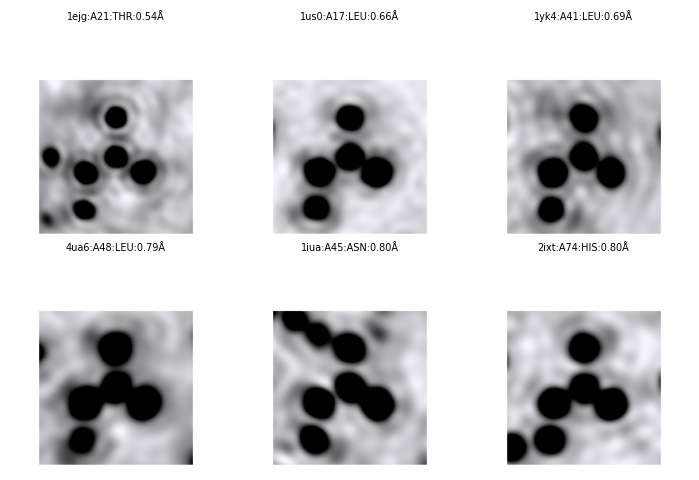

In [ ]:
# 1. Generate all six density arrays
# 2. Create the multi-panel figure directly from the arrays
# 3. Save as single publication PNG

fig, axes = plt.subplots(2, 3, figsize=(18/2.54, 12/2.54))

for ax, panel in zip(axes.flat, panels):
    # generate density array on the fly
    print(panel)
    pdb_code = panel['pdb_code']
    rid = panel['rid']
    title = panel['title']

    ml = mman.MapsManager().get_or_create(pdb_code, file=1, header=1, values=1)
    mf = mfun.MapFunctions(pdb_code, ml.mobj, ml.pobj, interpolation)

    ca = f"A:{rid}@C.A"
    la = f"A:{rid}@CA.A"
    pa = f"A:{rid}@O.A"

    cc = v3.VectorThree().from_coords(ml.pobj.get_coords_key(ca))
    ll = v3.VectorThree().from_coords(ml.pobj.get_coords_key(la))
    pp = v3.VectorThree().from_coords(ml.pobj.get_coords_key(pa))

    vals2d = mf.get_slice(cc, ll, pp, width, samples, interpolation, deriv=0, ret_type="2d")

    mplot = mph.MapPlotHelp("FIG")
    plotly_fig  = mplot.make_plot_slice_2d(vals2d,
                             max_percent=95,
                             samples=samples,
                             width=width,
                             title="",
                             plot_type="heatmap",
                             hue="WB")


    # Convert to image and load into matplotlib panel
    img_bytes = plotly_fig.to_image(format='png', width=400, height=400)
    img = Image.open(io.BytesIO(img_bytes))
    ax.imshow(img)
    ax.set_title(panel['title'], fontsize=7)
    ax.axis('off')

plt.tight_layout(pad=0.5)
plt.savefig('Figure01_rings_all.png', dpi=600, bbox_inches='tight')

In [ ]:
# 1. Generate all six density arrays as contour plots
# 2. Create the multi-panel figure directly from the arrays
# 3. Save as single publication PNG

fig, axes = plt.subplots(2, 3, figsize=(18/2.54, 12/2.54))

for ax, panel in zip(axes.flat, panels):
    # generate density array on the fly
    print(panel)
    pdb_code = panel['pdb_code']
    rid = panel['rid']
    title = panel['title']

    ml = mman.MapsManager().get_or_create(pdb_code, file=1, header=1, values=1)
    mf = mfun.MapFunctions(pdb_code, ml.mobj, ml.pobj, interpolation)

    ca = f"A:{rid}@C.A"
    la = f"A:{rid}@CA.A"
    pa = f"A:{rid}@O.A"

    cc = v3.VectorThree().from_coords(ml.pobj.get_coords_key(ca))
    ll = v3.VectorThree().from_coords(ml.pobj.get_coords_key(la))
    pp = v3.VectorThree().from_coords(ml.pobj.get_coords_key(pa))

    vals2d = mf.get_slice(cc, ll, pp, width, samples, interpolation, deriv=0, ret_type="2d")

    mplot = mph.MapPlotHelp("FIG")
    plotly_fig  = mplot.make_plot_slice_2d(vals2d,
                             max_percent=95,   # 85% of max density to enhance contrast of rings
                             samples=samples,
                             width=width,
                             title="",
                             plot_type="countour",
                             hue="WB")


    # Convert to image and load into matplotlib panel
    img_bytes = plotly_fig.to_image(format='png', width=400, height=400)
    img = Image.open(io.BytesIO(img_bytes))
    ax.imshow(img)
    ax.set_title(panel['title'], fontsize=7)
    ax.axis('off')

plt.tight_layout(pad=0.5)
plt.savefig('Figure01_rings_all.png', dpi=600, bbox_inches='tight')